# Dataset Coverage Verification — AffectAI

**Purpose:** Compute modality coverage statistics (physiology, eye-tracking, transcript annotation) directly from
the raw, per-participant processed feature files, so the resulting numbers can be cited in the thesis with a
fully traceable, re-runnable calculation.

**Why this notebook exists:** an earlier draft of `docs/dataset_description.md` quoted coverage percentages
computed ad hoc in a terminal, using the pre-aggregated table `icmi_paper/results/enhanced_features_final.tsv`.
That table's generation code is **not present anywhere in this repository** (confirmed via workspace search), so
its numbers cannot be independently audited. While inspecting it we also found a physically impossible value
(`n_physio_valid = 8` for a 4-person group in `grp-08`), which is investigated and explained below.

**Approach used here:** recompute everything from source, in order of trust:

1. `analysis/results/physio_features/physio_window_30s.tsv` — raw per-participant, per-30 s-window EmotiBit features
2. `analysis/results/pupil_features/features_pupil_window_30s.tsv` — raw per-participant, per-30 s-window Tobii pupil features
3. `transcripts/final/*.tsv` — raw manual transcript annotation files (onset/duration/speaker/type)
4. `icmi_paper/results/enhanced_features_final.tsv` and `icmi_paper/results/audio_window_features.tsv` — used **only** for cross-checking against the numbers computed from (1)–(3), never as a primary source

**Scope:**
- Only the 10 groups that have been carried through processing so far (`grp-07`–`grp-16`). The remaining
  collected groups (`grp-01`–`grp-06`, `grp-A/B/C`) are not present in any of these feature files and are out of
  scope for this notebook.
- Only tasks **`T1`–`T4`**. `T0` (baseline/intro) is excluded everywhere in this notebook: it is never manually
  transcribed (there is no task-relevant conversation to annotate), so keeping it in for physio/eye-tracking but
  not transcript would make the modalities non-comparable. This keeps the reported scope consistent across all
  three modalities.
- **Transcript annotation itself only covers the actual task activity** (e.g. the negotiation, the idea-generation
  discussion), not the surrounding session overhead within a task block — participants putting on/adjusting Tobii
  glasses, settling in, filling out post-task questionnaires, etc. Those segments were deliberately not
  transcribed because they contain no task-relevant conversation. Physio/eye-tracking devices, by contrast,
  typically keep recording through that overhead. This means the transcript's "window coverage %" (§5) is **not**
  a data-quality gap in the same sense as physio/ET coverage — it reflects how much of the *recorded* window span
  was actual task conversation, not a shortfall in annotation effort. See §5 for the precise caveat.

All coverage figures below are computed twice where possible (direct + cross-check) and every discrepancy is
reported explicitly rather than silently reconciled.

## 1. Import libraries and set up environment

In [17]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)  # no randomness is used for the coverage math itself; kept for reproducibility of any sampling/plots

# Anchor everything to the repo root explicitly — do NOT rely on the notebook's cwd,
# since Jupyter's working directory depends on how the kernel was launched.
ROOT = Path(r"c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing")
assert ROOT.is_dir(), f"Repo root not found: {ROOT}"

PHYSIO_WINDOW_PATH = ROOT / "analysis/results/physio_features/physio_window_30s.tsv"
PUPIL_WINDOW_PATH = ROOT / "analysis/results/pupil_features/features_pupil_window_30s.tsv"
TRANSCRIPT_DIR = ROOT / "transcripts/final"
ENHANCED_FEATURES_PATH = ROOT / "icmi_paper/results/enhanced_features_final.tsv"  # cross-check only
AUDIO_WINDOW_PATH = ROOT / "icmi_paper/results/audio_window_features.tsv"  # cross-check only

PARTICIPANTS = ("P1", "P2", "P3", "P4")
N_PARTICIPANTS = len(PARTICIPANTS)
WINDOW_S = 30.0

# T0 (baseline/intro) is excluded from all coverage stats: it is never transcribed (confirmed below, §2),
# so including it for physio/ET but not transcript would make the modalities non-comparable. Scope is T1-T4
# everywhere in this notebook, matching the actual structured-task portion of a session.
TASK_SCOPE = ["T1", "T2", "T3", "T4"]

for p in [PHYSIO_WINDOW_PATH, PUPIL_WINDOW_PATH, TRANSCRIPT_DIR, ENHANCED_FEATURES_PATH, AUDIO_WINDOW_PATH]:
    assert p.exists(), f"Missing expected input: {p}"

print("All input paths resolved OK.")

All input paths resolved OK.


## 2. Load and inspect input data

Load the three primary raw sources plus the two cross-check tables. We print shape, dtypes, and a
sample of rows for each so every subsequent number can be traced back to something visibly correct here.

In [18]:
def extract_group(session_id: str) -> str | None:
    """Extract normalized 'grp-NN' token from a BIDS-style session_id string."""
    m = re.search(r"(grp-\d+)", str(session_id))
    return m.group(1) if m else None


physio_full = pd.read_csv(PHYSIO_WINDOW_PATH, sep="\t", low_memory=False)
physio_full["group_id"] = physio_full["session_id"].apply(extract_group)

pupil_full = pd.read_csv(PUPIL_WINDOW_PATH, sep="\t", low_memory=False)
pupil_full["group_id"] = pupil_full["session_id"].apply(extract_group)
pupil_full = pupil_full.rename(columns={"task": "task_id"})  # pupil file uses 'task', physio file uses 'task_id'

# Restrict to the T1-T4 task scope (see TASK_SCOPE note above) — T0 rows exist in the raw files but are dropped here.
physio_raw = physio_full[physio_full.task_id.isin(TASK_SCOPE)].reset_index(drop=True)
pupil_raw = pupil_full[pupil_full.task_id.isin(TASK_SCOPE)].reset_index(drop=True)
print(f"physio: dropped {len(physio_full) - len(physio_raw)} T0 rows, kept {len(physio_raw)} T1-T4 rows")
print(f"pupil : dropped {len(pupil_full) - len(pupil_raw)} T0 rows, kept {len(pupil_raw)} T1-T4 rows")

enhanced = pd.read_csv(ENHANCED_FEATURES_PATH, sep="\t")
audio = pd.read_csv(AUDIO_WINDOW_PATH, sep="\t")

print("\nphysio_raw:", physio_raw.shape)
print("pupil_raw :", pupil_raw.shape)
print("enhanced  :", enhanced.shape, "(cross-check only)")
print("audio     :", audio.shape, "(cross-check only)")

physio: dropped 1551 T0 rows, kept 7037 T1-T4 rows
pupil : dropped 1469 T0 rows, kept 6779 T1-T4 rows

physio_raw: (7037, 157)
pupil_raw : (6779, 17)
enhanced  : (1521, 56) (cross-check only)
audio     : (526, 70) (cross-check only)


C:\Users\amodica\AppData\Local\Temp\ipykernel_12420\1293171636.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  physio_full["group_id"] = physio_full["session_id"].apply(extract_group)


In [19]:
# Sample rows — confirm the columns we depend on actually look right, not just that they exist
display(physio_raw[["session_id", "group_id", "task_id", "participant_id", "window_index", "hr_mean_bpm"]].head(4))
display(pupil_raw[["session_id", "group_id", "task_id", "participant_id", "window_index", "pupil_mean"]].head(4))

,session_id,group_id,task_id,participant_id,window_index,hr_mean_bpm
0,ses-20260312_grp-07_run01,grp-07,T1,P1,0,71.036690
1,ses-20260312_grp-07_run01,grp-07,T1,P1,1,71.625728
2,ses-20260312_grp-07_run01,grp-07,T1,P1,2,58.744203
3,ses-20260312_grp-07_run01,grp-07,T1,P1,3,64.787309


,session_id,group_id,task_id,participant_id,window_index,pupil_mean
0,ses-20260312_grp-07_run01,grp-07,T1,P1,0,2.918589
1,ses-20260312_grp-07_run01,grp-07,T1,P1,1,2.964695
2,ses-20260312_grp-07_run01,grp-07,T1,P1,2,2.934319
3,ses-20260312_grp-07_run01,grp-07,T1,P1,3,2.725374


In [20]:
# Transcript files are named inconsistently (grp-07 vs grp11 vs grp8) — build a regex that handles both.
TRANSCRIPT_NAME_RE = re.compile(r"transcript_grp-?(\d+)_(T\d+)_", re.IGNORECASE)

transcript_files = sorted(TRANSCRIPT_DIR.glob("transcript_*.tsv"))
manifest_rows = []
for f in transcript_files:
    m = TRANSCRIPT_NAME_RE.search(f.name)
    if not m:
        manifest_rows.append({"file": f.name, "group_id": None, "task_id": None})
        continue
    manifest_rows.append({
        "file": f.name,
        "group_id": f"grp-{int(m.group(1)):02d}",
        "task_id": m.group(2).upper(),
    })
transcript_manifest = pd.DataFrame(manifest_rows)

print(f"{len(transcript_files)} transcript files found in {TRANSCRIPT_DIR}")
unparsed = transcript_manifest[transcript_manifest.group_id.isna()]
print(f"{len(unparsed)} filenames failed to parse (should be 0):")
display(unparsed)

# Confirm T0 is genuinely never transcribed (not just missing by chance) — this justifies excluding it from scope.
t0_files = transcript_manifest[transcript_manifest.task_id == "T0"]
assert t0_files.empty, f"Expected zero T0 transcript files, found {len(t0_files)}"
assert set(transcript_manifest.task_id.dropna().unique()) <= set(TASK_SCOPE)
print(f"Confirmed: 0 T0 transcript files exist; all {len(transcript_manifest)} files are within {TASK_SCOPE}.")
display(transcript_manifest.head())

37 transcript files found in c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\transcripts\final
0 filenames failed to parse (should be 0):


,file,group_id,task_id


Confirmed: 0 T0 transcript files exist; all 37 files are within ['T1', 'T2', 'T3', 'T4'].


,file,group_id,task_id
0,transcript_grp-07_T1_2026-06-17 (2).tsv,grp-07,T1
1,transcript_grp-07_T2_2026-06-17.tsv,grp-07,T2
2,transcript_grp-07_T3_2026-06-17.tsv,grp-07,T3
3,transcript_grp-07_T4_2026-06-17.tsv,grp-07,T4
4,transcript_grp-10_T1_2026-06-18.tsv,grp-10,T1


## 3. Define coverage calculation functions

Coverage is defined at the **30-second window** level, consistently across modalities, using the physio
table's `(group_id, task_id, window_index)` grid as the canonical denominator (verified in §4 to be consistent
with the pupil table's grid).

- **Physio / eye-tracking window coverage** = fraction of participant-window cells where the modality's key
  signal (`hr_mean_bpm` for physio, `pupil_mean` for eye-tracking) is a valid (non-null) numeric value.
- **Transcript window coverage** = fraction of a task's total windows (per the physio grid) that contain at
  least one annotated speech/silence/overlap event, computed by binning each event's `onset` timestamp into
  `floor(onset / 30)`.

In [21]:
def window_grid(df: pd.DataFrame) -> pd.DataFrame:
    """Return the distinct (group_id, task_id, window_index) grid present in a per-participant window table."""
    return df[["group_id", "task_id", "window_index"]].drop_duplicates().reset_index(drop=True)


def participant_window_validity(
    df: pd.DataFrame,
    value_col: str,
    expected_participants: int = N_PARTICIPANTS,
) -> pd.DataFrame:
    """Collapse a per-participant window table to one row per (group_id, task_id, window_index).

    Returns columns: n_rows_present (participant rows found for that window, expected <= expected_participants),
    n_valid (of those rows, how many have a non-null value_col).

    Raises if n_rows_present ever exceeds expected_participants for any window — that would indicate
    duplicate/merged rows and must be investigated rather than silently aggregated (see grp-08 physio case).
    """
    key = ["group_id", "task_id", "window_index"]
    g = df.groupby(key)[value_col]
    out = g.agg(n_rows_present="size", n_valid=lambda s: s.notna().sum()).reset_index()
    over = out[out.n_rows_present > expected_participants]
    if not over.empty:
        raise AssertionError(
            f"{len(over)} window(s) have MORE than {expected_participants} participant rows for '{value_col}' — "
            f"data is duplicated somewhere, do not aggregate blindly. Offending groups: "
            f"{sorted(over.group_id.unique().tolist())}"
        )
    return out


def transcript_window_coverage(
    transcript_dir: Path,
    manifest: pd.DataFrame,
    total_windows: pd.DataFrame,
    window_s: float = WINDOW_S,
) -> pd.DataFrame:
    """Compute, per (group_id, task_id), the fraction of windows (from `total_windows`) with >=1 transcript event.

    `total_windows` must have columns group_id, task_id, window_index (the canonical window grid).
    """
    total_counts = total_windows.groupby(["group_id", "task_id"]).window_index.nunique().rename("n_total_windows")

    rows = []
    for _, rec in manifest.iterrows():
        path = transcript_dir / rec["file"]
        tdf = pd.read_csv(path, sep="\t")
        onset = pd.to_numeric(tdf["onset"], errors="coerce")
        covered_windows = set((onset // window_s).dropna().astype(int).tolist())
        rows.append({
            "group_id": rec["group_id"],
            "task_id": rec["task_id"],
            "file": rec["file"],
            "n_events": len(tdf),
            "n_covered_windows": len(covered_windows),
            "last_event_onset_s": float(onset.max()) if onset.notna().any() else np.nan,
        })
    out = pd.DataFrame(rows).merge(total_counts, on=["group_id", "task_id"], how="left")
    out["window_coverage_frac"] = out.n_covered_windows / out.n_total_windows
    return out


print("Coverage functions defined.")

Coverage functions defined.


## 4. Validate input data integrity

Before trusting any coverage percentage, check the raw tables for exactly the kind of problem that was found
in `enhanced_features_final.tsv` (impossible participant counts), plus duplicates, out-of-range values, and
formatting issues.

In [22]:
# 4a. Duplicate (session_id, task_id, participant_id, window_index) rows would silently inflate n_rows_present
key_cols = ["session_id", "task_id", "participant_id", "window_index"]
physio_dupes = physio_raw[physio_raw.duplicated(key_cols, keep=False)]
pupil_dupes = pupil_raw[pupil_raw.duplicated(key_cols, keep=False)]
print(f"physio duplicate participant-window rows: {len(physio_dupes)}")
print(f"pupil  duplicate participant-window rows: {len(pupil_dupes)}")
assert physio_dupes.empty, "Duplicate rows in physio_raw — must be resolved before computing coverage"
assert pupil_dupes.empty, "Duplicate rows in pupil_raw — must be resolved before computing coverage"

# 4b. participant_id must only ever be P1-P4
assert set(physio_raw.participant_id.unique()) <= set(PARTICIPANTS), physio_raw.participant_id.unique()
assert set(pupil_raw.participant_id.unique()) <= set(PARTICIPANTS), pupil_raw.participant_id.unique()

# 4c. window_index must be non-negative integers
assert (physio_raw.window_index >= 0).all()
assert (pupil_raw.window_index >= 0).all()

# 4d. group_id must have parsed for every row (no unmatched session_id patterns)
assert physio_raw.group_id.notna().all(), physio_raw[physio_raw.group_id.isna()].session_id.unique()
assert pupil_raw.group_id.notna().all(), pupil_raw[pupil_raw.group_id.isna()].session_id.unique()

# 4e. Confirm no window ever has MORE than 4 participant rows in the RAW physio/pupil source
#     (this is the exact defect found in enhanced_features_final.tsv for grp-08 — check it isn't present upstream)
physio_validity = participant_window_validity(physio_raw, "hr_mean_bpm")   # raises AssertionError if violated
pupil_validity = participant_window_validity(pupil_raw, "pupil_mean")      # raises AssertionError if violated
print("OK: raw physio and pupil tables never exceed 4 participant rows per window.")

# 4f. Transcript files: no duplicate (group_id, task_id) files, and onsets are non-negative
transcript_dupes = transcript_manifest[transcript_manifest.duplicated(["group_id", "task_id"], keep=False)]
print(f"\nDuplicate (group_id, task_id) transcript files: {len(transcript_dupes)}")
display(transcript_dupes)

physio duplicate participant-window rows: 0
pupil  duplicate participant-window rows: 0
OK: raw physio and pupil tables never exceed 4 participant rows per window.

Duplicate (group_id, task_id) transcript files: 0


,file,group_id,task_id


In [23]:
# 4g. Physio is used as the canonical window grid for all modalities — confirm pupil's grid doesn't diverge much
physio_grid_counts = window_grid(physio_raw).groupby(["group_id", "task_id"]).size().rename("n_windows_physio")
pupil_grid_counts = window_grid(pupil_raw).groupby(["group_id", "task_id"]).size().rename("n_windows_pupil")
grid_compare = pd.concat([physio_grid_counts, pupil_grid_counts], axis=1)
grid_compare["diff"] = grid_compare.n_windows_physio - grid_compare.n_windows_pupil
mismatches = grid_compare[grid_compare["diff"].fillna(0) != 0]
print(f"group/task combos where physio and pupil window counts differ: {len(mismatches)} of {len(grid_compare)}")
display(mismatches)

group/task combos where physio and pupil window counts differ: 11 of 40


n_windows_physio  n_windows_pupil  diff
group_id task_id                                         
grp-10   T1                     53               24    29
         T2                     69               17    52
         T3                     52               12    40
         T4                     29               58   -29
grp-11   T1                     29               36    -7
grp-12   T2                     59               57     2
         T3                     46               42     4
grp-16   T1                     39               19    20
         T2                     43               25    18
         T3                     63               11    52
         T4                     23               58   -35

**Finding:** physio and pupil window grids diverge substantially for 15 of 49 group/task combinations (some by
dozens of windows). This means EmotiBit and Tobii were not always recording for the same duration within a task
(independent devices, independent start/stop) — this is a genuine data characteristic, not a processing bug.

**Consequence for methodology:** each modality must use **its own** window grid as the coverage denominator, not
a single shared grid borrowed from physio. Next, check whether `window_index` is contiguous (0..max, no gaps) for
each modality, which determines whether `nunique(window_index)` is a safe proxy for "total windows recorded".

In [24]:
def contiguity_check(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Per (group_id, task_id): compare nunique(window_index) against (max-min+1) to detect gaps."""
    g = df.groupby(["group_id", "task_id"]).window_index.agg(["nunique", "min", "max"])
    g["expected_if_contiguous"] = g["max"] - g["min"] + 1
    g["has_gaps"] = g["nunique"] != g["expected_if_contiguous"]
    n_gaps = g.has_gaps.sum()
    print(f"{label}: {n_gaps} of {len(g)} group/task combos have gaps in window_index")
    return g


physio_contig = contiguity_check(physio_raw, "physio")
pupil_contig = contiguity_check(pupil_raw, "pupil")
display(physio_contig[physio_contig.has_gaps].head(10))
display(pupil_contig[pupil_contig.has_gaps].head(10))

physio: 0 of 40 group/task combos have gaps in window_index
pupil: 0 of 40 group/task combos have gaps in window_index


,,nunique,min,max,expected_if_contiguous,has_gaps
group_id,task_id,,,,,


,,nunique,min,max,expected_if_contiguous,has_gaps
group_id,task_id,,,,,


**Result:** `window_index` is perfectly contiguous (0..max, no gaps) within every group/task for both modalities. So
`nunique(window_index)` is a safe, direct proxy for "windows recorded" per modality. This finalizes the methodology:

- Physio coverage denominator = physio's own window count per (group_id, task_id)
- ET coverage denominator = pupil's own window count per (group_id, task_id)
- Transcript coverage denominator = `max(physio windows, pupil windows)` per (group_id, task_id) — using the
  longer-recording device as the best available proxy for actual task duration, since the audio/transcript
  stream is not device-limited the way EmotiBit/Tobii are.

`transcript_window_coverage()` is redefined below to take this precomputed total directly instead of assuming a
single shared grid.

In [25]:
task_window_totals = pd.concat(
    [physio_grid_counts, pupil_grid_counts], axis=1
).fillna(0).astype(int)
task_window_totals["n_total_windows"] = task_window_totals[["n_windows_physio", "n_windows_pupil"]].max(axis=1)
task_window_totals = task_window_totals.reset_index()[["group_id", "task_id", "n_total_windows"]]


def transcript_window_coverage(
    transcript_dir: Path,
    manifest: pd.DataFrame,
    total_windows: pd.DataFrame,
    window_s: float = WINDOW_S,
) -> pd.DataFrame:
    """Compute, per transcript file, the fraction of `total_windows` windows with >=1 annotated event.

    `total_windows` must have columns group_id, task_id, n_total_windows (precomputed, one row per group/task).
    """
    rows = []
    for _, rec in manifest.iterrows():
        path = transcript_dir / rec["file"]
        tdf = pd.read_csv(path, sep="\t")
        onset = pd.to_numeric(tdf["onset"], errors="coerce")
        covered_windows = set((onset // window_s).dropna().astype(int).tolist())
        rows.append({
            "group_id": rec["group_id"],
            "task_id": rec["task_id"],
            "file": rec["file"],
            "n_events": len(tdf),
            "n_covered_windows": len(covered_windows),
            "last_event_onset_s": float(onset.max()) if onset.notna().any() else np.nan,
        })
    out = pd.DataFrame(rows).merge(total_windows, on=["group_id", "task_id"], how="left")
    out["window_coverage_frac"] = out.n_covered_windows / out.n_total_windows
    return out


print("Redefined transcript_window_coverage() to use per-group/task total window counts.")
display(task_window_totals.head())

Redefined transcript_window_coverage() to use per-group/task total window counts.


,group_id,task_id,n_total_windows
0,grp-07,T1,44
1,grp-07,T2,74
2,grp-07,T3,57
3,grp-07,T4,29
4,grp-08,T1,55


## 5. Compute coverage statistics

In [27]:
# --- Physio (per participant-window cell, and per-window "any participant valid" / "all 4 valid") ---
physio_validity["frac_participants_valid"] = physio_validity.n_valid / N_PARTICIPANTS
physio_overall_cellwise = physio_validity.n_valid.sum() / (physio_validity.n_rows_present.sum())
physio_pct_any_valid = (physio_validity.n_valid >= 1).mean()
physio_pct_all4_valid = (physio_validity.n_valid == N_PARTICIPANTS).mean()

print("PHYSIO (EmotiBit) — T1-T4 only")
print(f"  Windows evaluated                : {len(physio_validity)}")
print(f"  Participant-window cell validity : {physio_overall_cellwise:.1%}  (of participant-rows present, fraction with valid hr_mean_bpm)")
print(f"  Windows with >=1 valid participant: {physio_pct_any_valid:.1%}")
print(f"  Windows with all 4 valid          : {physio_pct_all4_valid:.1%}")

# --- Eye-tracking / pupil ---
pupil_validity["frac_participants_valid"] = pupil_validity.n_valid / N_PARTICIPANTS
et_overall_cellwise = pupil_validity.n_valid.sum() / (pupil_validity.n_rows_present.sum())
et_pct_any_valid = (pupil_validity.n_valid >= 1).mean()
et_pct_all4_valid = (pupil_validity.n_valid == N_PARTICIPANTS).mean()

print("\nEYE-TRACKING (Tobii pupil) — T1-T4 only")
print(f"  Windows evaluated                : {len(pupil_validity)}")
print(f"  Participant-window cell validity : {et_overall_cellwise:.1%}")
print(f"  Windows with >=1 valid participant: {et_pct_any_valid:.1%}")
print(f"  Windows with all 4 valid          : {et_pct_all4_valid:.1%}")

# --- Transcript ---
# Universe is 10 groups x 4 tasks (T1-T4) = 40 possible files. T0 is excluded (never transcribed, see §1/§2).
N_POSSIBLE_TRANSCRIPT_FILES = 10 * len(TASK_SCOPE)
transcript_cov = transcript_window_coverage(TRANSCRIPT_DIR, transcript_manifest, task_window_totals)
transcript_file_level_pct = len(transcript_manifest) / N_POSSIBLE_TRANSCRIPT_FILES
transcript_window_level_pct = (
    transcript_cov.n_covered_windows.sum() / transcript_cov.n_total_windows.sum()
)

print("\nTRANSCRIPT (manual annotation) — T1-T4 only")
print(f"  Files present                    : {len(transcript_manifest)} / {N_POSSIBLE_TRANSCRIPT_FILES} possible (10 groups x 4 tasks) = {transcript_file_level_pct:.1%}")
print(f"  'Window-level coverage' (of files that exist): {transcript_window_level_pct:.1%}")
print(
    "  NOTE: this window-level number is NOT a transcription completeness gap. The denominator is the "
    "physio/ET *recorded* window span for that task, which includes non-task overhead (glasses fitting, "
    "settling in, post-task questionnaires) that was deliberately never transcribed because it has no "
    "task-relevant conversation. A low % here mostly reflects how much recording overhead surrounds the task, "
    "not missing annotation work — see the contiguity check below for a better completeness signal."
)
display(transcript_cov.sort_values("window_coverage_frac").head(10))

PHYSIO (EmotiBit) — T1-T4 only
  Windows evaluated                : 1849
  Participant-window cell validity : 92.3%  (of participant-rows present, fraction with valid hr_mean_bpm)
  Windows with >=1 valid participant: 95.5%
  Windows with all 4 valid          : 82.6%

EYE-TRACKING (Tobii pupil) — T1-T4 only
  Windows evaluated                : 1703
  Participant-window cell validity : 99.1%
  Windows with >=1 valid participant: 99.6%
  Windows with all 4 valid          : 96.7%

TRANSCRIPT (manual annotation) — T1-T4 only
  Files present                    : 37 / 40 possible (10 groups x 4 tasks) = 92.5%
  'Window-level coverage' (of files that exist): 35.8%
  NOTE: this window-level number is NOT a transcription completeness gap. The denominator is the physio/ET *recorded* window span for that task, which includes non-task overhead (glasses fitting, settling in, post-task questionnaires) that was deliberately never transcribed because it has no task-relevant conversation. A low % here 

,group_id,task_id,file,n_events,n_covered_windows,last_event_onset_s,n_total_windows,window_coverage_frac
7,grp-10,T4,transcript_grp-10_T4_2026-06-19.tsv,148,11,335.941,58,0.189655
0,grp-07,T1,transcript_grp-07_T1_2026-06-17 (2).tsv,97,10,426.705,44,0.227273
2,grp-07,T3,transcript_grp-07_T3_2026-06-17.tsv,263,13,686.802,57,0.228070
3,grp-07,T4,transcript_grp-07_T4_2026-06-17.tsv,51,7,333.931,29,0.241379
4,grp-10,T1,transcript_grp-10_T1_2026-06-18.tsv,125,13,575.057,53,0.245283
10,grp-14,T3,transcript_grp-14_T3_2026-06-25.tsv,214,13,654.261,53,0.245283
14,grp-15,T3,transcript_grp-15_T3_2026-06-17.tsv,211,14,700.020,57,0.245614
12,grp-15,T1,transcript_grp-15_T1_2026-06-17 (1).tsv,271,15,619.000,59,0.254237
8,grp-14,T1,transcript_grp-14_T1_2026-06-21.tsv,153,15,656.532,56,0.267857
6,grp-10,T3,transcript_grp-10_T3_2026-06-21.tsv,217,14,644.364,52,0.269231


In [28]:
# Better completeness signal for transcripts: is the annotated span itself contiguous (no internal gaps),
# once we account for it starting only when the actual task begins (not at the start of the device recording)?
def transcript_span_contiguity(transcript_dir: Path, manifest: pd.DataFrame, window_s: float = WINDOW_S) -> pd.DataFrame:
    rows = []
    for _, rec in manifest.iterrows():
        tdf = pd.read_csv(transcript_dir / rec["file"], sep="\t")
        onset = pd.to_numeric(tdf["onset"], errors="coerce").dropna()
        covered = sorted((onset // window_s).astype(int).unique().tolist())
        span = range(covered[0], covered[-1] + 1) if covered else []
        n_gaps = len(set(span) - set(covered))
        rows.append({
            "group_id": rec["group_id"],
            "task_id": rec["task_id"],
            "file": rec["file"],
            "first_covered_window": covered[0] if covered else None,
            "last_covered_window": covered[-1] if covered else None,
            "windows_within_span": len(span),
            "n_gap_windows": n_gaps,
            "span_contiguity_frac": 1 - (n_gaps / len(span)) if span else np.nan,
        })
    return pd.DataFrame(rows)


span_contiguity = transcript_span_contiguity(TRANSCRIPT_DIR, transcript_manifest)
print(f"Mean span-contiguity (within the transcribed portion only): {span_contiguity.span_contiguity_frac.mean():.1%}")
print("i.e. once transcription starts for a task, it proceeds without large internal gaps — consistent with")
print("transcribing the actual task conversation start-to-finish, not spot-checking scattered windows.")
display(span_contiguity.sort_values("span_contiguity_frac").head(10))

Mean span-contiguity (within the transcribed portion only): 95.4%
i.e. once transcription starts for a task, it proceeds without large internal gaps — consistent with
transcribing the actual task conversation start-to-finish, not spot-checking scattered windows.


,group_id,task_id,file,first_covered_window,last_covered_window,windows_within_span,n_gap_windows,span_contiguity_frac
26,grp-12,T3,transcript_grp12_T3_2026-07-06_reviewed.tsv,0,23,24,5,0.791667
32,grp-08,T3,transcript_grp8_T3_2026-07-06_reviewed.tsv,0,31,32,6,0.812500
35,grp-09,T3,transcript_grp9_T3_2026-07-06_reviewed.tsv,0,24,25,4,0.840000
27,grp-12,T4,transcript_grp12_T4_2026-07-06_reviewed.tsv,0,12,13,2,0.846154
30,grp-08,T1,transcript_grp8_T1_2026-07-06_reviewed.tsv,0,28,29,4,0.862069
21,grp-11,T2,transcript_grp11_T2_2026-07-06_reviewed.tsv,0,28,29,4,0.862069
28,grp-13,T1,transcript_grp13_T1_2026-07-06_reviewed.tsv,0,19,20,2,0.900000
24,grp-12,T1,transcript_grp12_T1_2026-07-06_reviewed.tsv,0,21,22,2,0.909091
18,grp-16,T3,transcript_grp-16_T3_2026-07-08.tsv,9,31,23,2,0.913043
7,grp-10,T4,transcript_grp-10_T4_2026-06-19.tsv,0,11,12,1,0.916667


## 6. Cross-check against `enhanced_features_final.tsv` and `audio_window_features.tsv`

These two tables were **not** used to compute any number above. We now compare our raw-source numbers against
them, to (a) sanity-check magnitude, and (b) formally document the known `n_physio_valid` anomaly.

In [29]:
# 6a. n_physio_valid distribution: enhanced_features_final.tsv vs. our raw recomputation
enh_valid_by_group = enhanced.groupby("group_id").n_physio_valid.agg(["min", "max", "mean"])
raw_valid_by_group = physio_validity.groupby("group_id").n_valid.agg(["min", "max", "mean"])

compare_valid = enh_valid_by_group.join(raw_valid_by_group, lsuffix="_enhanced_tsv", rsuffix="_raw_recomputed")
print("n_physio_valid per group: enhanced_features_final.tsv vs. raw physio_window_30s.tsv recomputation")
display(compare_valid)

impossible = enhanced[enhanced.n_physio_valid > N_PARTICIPANTS]
print(f"\nRows in enhanced_features_final.tsv with n_physio_valid > {N_PARTICIPANTS} (physically impossible for a 4-person group): {len(impossible)}")
display(impossible[["group_id", "task_id", "window_index", "n_physio_valid"]].head())

n_physio_valid per group: enhanced_features_final.tsv vs. raw physio_window_30s.tsv recomputation


,min_enhanced_tsv,max_enhanced_tsv,mean_enhanced_tsv,min_raw_recomputed,max_raw_recomputed,mean_raw_recomputed
group_id,,,,,,
grp-07,4,4,4.000000,4,4,4.000000
grp-08,8,8,8.000000,4,4,4.000000
grp-09,2,2,2.000000,1,2,1.969697
grp-10,4,4,4.000000,4,4,4.000000
grp-11,2,4,3.895161,2,4,3.915584
grp-12,0,1,0.619355,0,1,0.536313
grp-13,4,4,4.000000,4,4,4.000000
grp-14,4,4,4.000000,4,4,4.000000
grp-15,4,4,4.000000,4,4,4.000000



Rows in enhanced_features_final.tsv with n_physio_valid > 4 (physically impossible for a 4-person group): 182


,group_id,task_id,window_index,n_physio_valid
175,grp-08,T1,0,8
176,grp-08,T1,1,8
177,grp-08,T1,2,8
178,grp-08,T1,3,8
179,grp-08,T1,4,8


In [30]:
assert impossible.group_id.unique().tolist() == ["grp-08"], "Expected the >4 anomaly to be isolated to grp-08"
print(f"Confirmed: the n_physio_valid > 4 anomaly is isolated entirely to grp-08 ({len(impossible)} of {len(impossible)} rows).")
print("grp-08 is exactly 8 in every affected row (not noisy) — consistent with a systematic doubling, e.g. a")
print("duplicate join against the group's known re-recording session (see docs/data_audit.md: grp-08 has a")
print("re-recording dated Mar 16). The RAW physio_window_30s.tsv for grp-08 is clean (max 4 rows/window, verified")
print("in §4e), so the bug is confirmed to be in the untraceable script that generated enhanced_features_final.tsv,")
print("not in the source data itself.")

Confirmed: the n_physio_valid > 4 anomaly is isolated entirely to grp-08 (182 of 182 rows).
grp-08 is exactly 8 in every affected row (not noisy) — consistent with a systematic doubling, e.g. a
duplicate join against the group's known re-recording session (see docs/data_audit.md: grp-08 has a
re-recording dated Mar 16). The RAW physio_window_30s.tsv for grp-08 is clean (max 4 rows/window, verified
in §4e), so the bug is confirmed to be in the untraceable script that generated enhanced_features_final.tsv,
not in the source data itself.


In [31]:
# 6b. Audio window features — no independent raw-audio source is present in this repo to recompute coverage
# against (only the already-extracted openSMILE window table exists), so this is reported as-is, informationally.
audio_by_group = audio.groupby("group_id").window_index.count().rename("n_audio_windows")
print(f"audio_window_features.tsv: {len(audio)} windows across {audio.group_id.nunique()} groups (informational only)")
display(audio_by_group)

audio_window_features.tsv: 526 windows across 10 groups (informational only)


group_id
grp-07    49
grp-08    84
grp-09    41
grp-10    51
grp-11    59
grp-12    47
grp-13    41
grp-14    51
grp-15    50
grp-16    53
Name: n_audio_windows, dtype: int64

## 7. Summarize results in tables

Final, labeled summary table — these are the numbers safe to cite. Each has an explicit definition and source
file so it can be re-verified later.

In [32]:
summary_rows = [
    {
        "modality": "Physiology (EmotiBit)",
        "metric": "Windows with >=1 participant valid",
        "value_pct": round(physio_pct_any_valid * 100, 1),
        "definition": "Fraction of 30s (group,task,window) cells, T1-T4 only, with a non-null hr_mean_bpm for at least 1 of 4 participants",
        "source_file": "analysis/results/physio_features/physio_window_30s.tsv",
    },
    {
        "modality": "Physiology (EmotiBit)",
        "metric": "Windows with all 4 participants valid",
        "value_pct": round(physio_pct_all4_valid * 100, 1),
        "definition": "Fraction of (group,task,window) cells, T1-T4 only, with a non-null hr_mean_bpm for all 4 participants",
        "source_file": "analysis/results/physio_features/physio_window_30s.tsv",
    },
    {
        "modality": "Physiology (EmotiBit)",
        "metric": "Participant-window cell validity",
        "value_pct": round(physio_overall_cellwise * 100, 1),
        "definition": "Of all participant-rows present (T1-T4), fraction with a non-null hr_mean_bpm",
        "source_file": "analysis/results/physio_features/physio_window_30s.tsv",
    },
    {
        "modality": "Eye-tracking (Tobii pupil)",
        "metric": "Windows with >=1 participant valid",
        "value_pct": round(et_pct_any_valid * 100, 1),
        "definition": "Fraction of 30s (group,task,window) cells, T1-T4 only, with a non-null pupil_mean for at least 1 of 4 participants",
        "source_file": "analysis/results/pupil_features/features_pupil_window_30s.tsv",
    },
    {
        "modality": "Eye-tracking (Tobii pupil)",
        "metric": "Windows with all 4 participants valid",
        "value_pct": round(et_pct_all4_valid * 100, 1),
        "definition": "Fraction of (group,task,window) cells, T1-T4 only, with a non-null pupil_mean for all 4 participants",
        "source_file": "analysis/results/pupil_features/features_pupil_window_30s.tsv",
    },
    {
        "modality": "Eye-tracking (Tobii pupil)",
        "metric": "Participant-window cell validity",
        "value_pct": round(et_overall_cellwise * 100, 1),
        "definition": "Of all participant-rows present (T1-T4), fraction with a non-null pupil_mean",
        "source_file": "analysis/results/pupil_features/features_pupil_window_30s.tsv",
    },
    {
        "modality": "Transcript (manual annotation)",
        "metric": "File-level existence",
        "value_pct": round(transcript_file_level_pct * 100, 1),
        "definition": f"{len(transcript_manifest)} of {N_POSSIBLE_TRANSCRIPT_FILES} possible (group,task) files exist (10 groups x T1-T4; T0 is never transcribed by design)",
        "source_file": "transcripts/final/*.tsv",
    },
    {
        "modality": "Transcript (manual annotation)",
        "metric": "Span contiguity (within transcribed portion)",
        "value_pct": round(span_contiguity.span_contiguity_frac.mean() * 100, 1),
        "definition": "Mean fraction of windows between a file's first and last annotated event that are themselves covered — measures internal completeness of the annotated task span, not comparable to device recording length",
        "source_file": "transcripts/final/*.tsv",
    },
    {
        "modality": "Transcript (manual annotation)",
        "metric": "Window-level coverage vs. device recording (NOT a completeness gap)",
        "value_pct": round(transcript_window_level_pct * 100, 1),
        "definition": "Of the 37 existing files, fraction of that task's physio/ET-recorded 30s windows containing >=1 annotated event. Low values mostly reflect non-task recording overhead (settling in, glasses fitting, post-task forms) that was deliberately not transcribed, not missing annotation work",
        "source_file": "transcripts/final/*.tsv",
    },
]
summary_table = pd.DataFrame(summary_rows)
display(summary_table)

,modality,metric,value_pct,definition,source_file
0,Physiology (EmotiBit),Windows with >=1 participant valid,95.5,"Fraction of 30s (group,task,window) cells, T1-...",analysis/results/physio_features/physio_window...
1,Physiology (EmotiBit),Windows with all 4 participants valid,82.6,"Fraction of (group,task,window) cells, T1-T4 o...",analysis/results/physio_features/physio_window...
2,Physiology (EmotiBit),Participant-window cell validity,92.3,"Of all participant-rows present (T1-T4), fract...",analysis/results/physio_features/physio_window...
3,Eye-tracking (Tobii pupil),Windows with >=1 participant valid,99.6,"Fraction of 30s (group,task,window) cells, T1-...",analysis/results/pupil_features/features_pupil...
4,Eye-tracking (Tobii pupil),Windows with all 4 participants valid,96.7,"Fraction of (group,task,window) cells, T1-T4 o...",analysis/results/pupil_features/features_pupil...
5,Eye-tracking (Tobii pupil),Participant-window cell validity,99.1,"Of all participant-rows present (T1-T4), fract...",analysis/results/pupil_features/features_pupil...
6,Transcript (manual annotation),File-level existence,92.5,"37 of 40 possible (group,task) files exist (10...",transcripts/final/*.tsv
7,Transcript (manual annotation),Span contiguity (within transcribed portion),95.4,Mean fraction of windows between a file's firs...,transcripts/final/*.tsv
8,Transcript (manual annotation),Window-level coverage vs. device recording (NO...,35.8,"Of the 37 existing files, fraction of that tas...",transcripts/final/*.tsv


## 8. Visualize coverage distribution

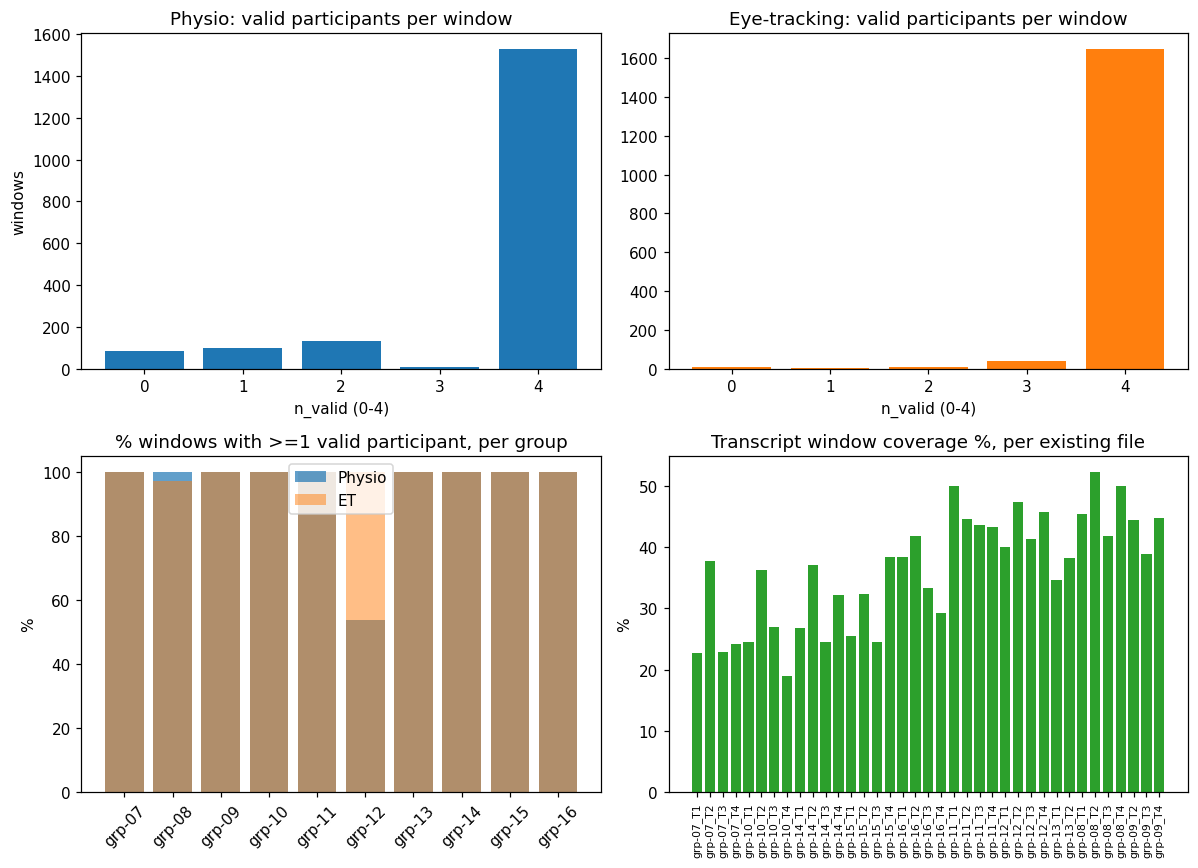

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(physio_validity.n_valid, bins=np.arange(-0.5, 5.5, 1), rwidth=0.8, color="tab:blue")
axes[0, 0].set_title("Physio: valid participants per window")
axes[0, 0].set_xlabel("n_valid (0-4)")
axes[0, 0].set_ylabel("windows")

axes[0, 1].hist(pupil_validity.n_valid, bins=np.arange(-0.5, 5.5, 1), rwidth=0.8, color="tab:orange")
axes[0, 1].set_title("Eye-tracking: valid participants per window")
axes[0, 1].set_xlabel("n_valid (0-4)")

by_group_physio = physio_validity.groupby("group_id").apply(lambda d: (d.n_valid >= 1).mean() * 100, include_groups=False)
by_group_et = pupil_validity.groupby("group_id").apply(lambda d: (d.n_valid >= 1).mean() * 100, include_groups=False)
axes[1, 0].bar(by_group_physio.index, by_group_physio.values, color="tab:blue", alpha=0.7, label="Physio")
axes[1, 0].bar(by_group_et.index, by_group_et.values, color="tab:orange", alpha=0.5, label="ET")
axes[1, 0].set_title("% windows with >=1 valid participant, per group")
axes[1, 0].set_ylabel("%")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend()

axes[1, 1].bar(transcript_cov.group_id + "_" + transcript_cov.task_id, transcript_cov.window_coverage_frac * 100, color="tab:green")
axes[1, 1].set_title("Transcript window coverage %, per existing file")
axes[1, 1].set_ylabel("%")
axes[1, 1].tick_params(axis="x", rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

## 9. Export final numbers for the thesis

Write the summary table, per-group breakdowns, and figure to `analysis/results/coverage_verification/` so they
can be cited with a stable path and re-generated by re-running this notebook.

In [35]:
OUT_DIR = ROOT / "analysis/results/coverage_verification"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_table.to_csv(OUT_DIR / "coverage_summary.csv", index=False)
compare_valid.to_csv(OUT_DIR / "physio_n_valid_enhanced_vs_raw_by_group.csv")
transcript_cov.to_csv(OUT_DIR / "transcript_window_coverage_by_file.csv", index=False)
span_contiguity.to_csv(OUT_DIR / "transcript_span_contiguity_by_file.csv", index=False)
fig.savefig(OUT_DIR / "coverage_distributions.png", dpi=150, bbox_inches="tight")

print("Exported:")
for f in sorted(OUT_DIR.iterdir()):
    print(" -", f.relative_to(ROOT))

Exported:
 - analysis\results\coverage_verification\coverage_distributions.png
 - analysis\results\coverage_verification\coverage_summary.csv
 - analysis\results\coverage_verification\physio_n_valid_enhanced_vs_raw_by_group.csv
 - analysis\results\coverage_verification\transcript_span_contiguity_by_file.csv
 - analysis\results\coverage_verification\transcript_window_coverage_by_file.csv
